In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from riap.api import load_config, Riap

### 1. Initiate the analyzer

In [26]:
# 1. using a config gfile
cfg = load_config("IMPV2.yaml")
# riap_analyser = Riap(cfg)

# 2. overriding specific parameters
riap_analyser = Riap(
    cfg,
    data_path = "/media/elea/2TBBackUp/Nathan/2_FIXATION/data/Solution1/",
    path_output = "/media/elea/2TBBackUp/Nathan/2_FIXATION/results/Solution1/",
    alignment_method = "MatchAnything"
)

2026-02-27 00:29:16.723 | INFO     | riap.api:__init__:96 - Data path set to: /media/elea/2TBBackUp/Nathan/2_FIXATION/data/Solution1
2026-02-27 00:29:16.726 | INFO     | riap.api:__init__:145 - Alignment method set to: MatchAnything
2026-02-27 00:29:16.727 | INFO     | riap.api:__init__:152 - Output path set to: /media/elea/2TBBackUp/Nathan/2_FIXATION/results/Solution1
2026-02-27 00:29:16.728 | INFO     | riap.api:__init__:174 - Force recompute set to: False
2026-02-27 00:29:16.729 | INFO     | riap.api:__init__:179 - Input parameters validated successfully
2026-02-27 00:29:16.729 | INFO     | riap.api:__init__:180 - Riap instance initiated successfully

2026-02-27 00:29:16.730 | INFO     | riap.api:__init__:185 - Alignment folders will be available in: /home/elea/Documents/HORAO/repositories/RIAP/temp
2026-02-27 00:29:16.731 | INFO     | riap.api:__init__:188 - Base directories identified: ['/media/elea/2TBBackUp/Nathan/2_FIXATION/data/Solution1/2026-02-04_181925_F_OR_HORAO_6002_004',

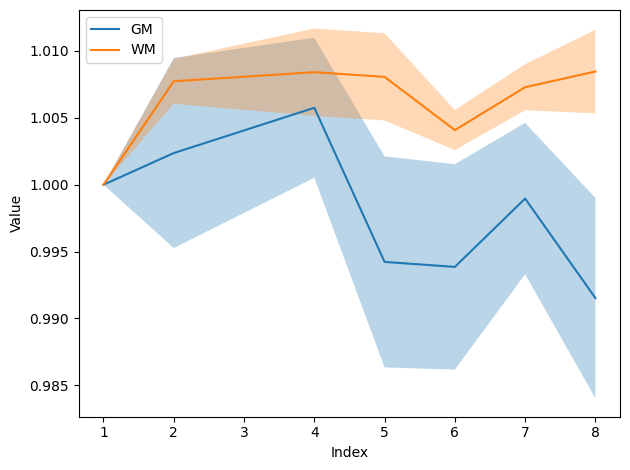

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your Excel file
file_path = riap_analyser.output_path / "totP_prism_CV.xlsx"  # adjust if needed

# Load Excel file (first column is index)
df = pd.read_excel(file_path, index_col=0)

# Split columns into two conditions
num_columns = df.shape[1]
split_index = num_columns // 2

condition1 = df.iloc[:, :split_index]
condition2 = df.iloc[:, split_index:]

# Number of samples per condition
n1 = condition1.shape[1]
n2 = condition2.shape[1]

# Row-wise statistics
mean1 = condition1.mean(axis=1) 
std1 = condition1.std(axis=1)
sem1 = std1 / np.sqrt(n1)
ci1 = 1.96 * sem1

mean2 = condition2.mean(axis=1)
std2 = condition2.std(axis=1)
sem2 = std2 / np.sqrt(n2)
ci2 = 1.96 * sem2

# Plot
plt.figure()

# Condition 1
plt.plot(df.index, mean1, linestyle='-', label = 'GM')
plt.fill_between(df.index, mean1 - ci1, mean1 + ci1, alpha=0.3)

# Condition 2
plt.plot(df.index, mean2, linestyle='-', label = 'WM')
plt.fill_between(df.index, mean2 - ci2, mean2 + ci2, alpha=0.3)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

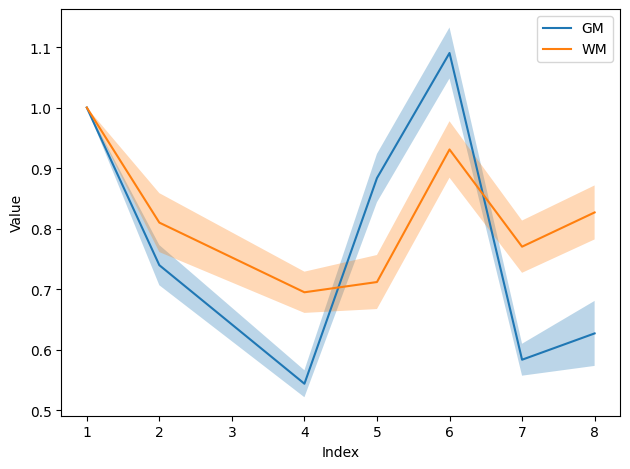

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your Excel file
file_path = riap_analyser.output_path / "linR_prism_cv.xlsx"  # adjust if needed
# Load Excel file (first column is index)
df = pd.read_excel(file_path, index_col=0)

# Split columns into two conditions
num_columns = df.shape[1]
split_index = num_columns // 2

condition1 = df.iloc[:, :split_index]
condition2 = df.iloc[:, split_index:]

# Number of samples per condition
n1 = condition1.shape[1]
n2 = condition2.shape[1]

# Row-wise statistics
mean1 = condition1.mean(axis=1) 
std1 = condition1.std(axis=1)
sem1 = std1 / np.sqrt(n1)
ci1 = 1.96 * sem1

mean2 = condition2.mean(axis=1)
std2 = condition2.std(axis=1)
sem2 = std2 / np.sqrt(n2)
ci2 = 1.96 * sem2

# Plot
plt.figure()

# Condition 1
plt.plot(df.index, mean1, linestyle='-', label = 'GM')
plt.fill_between(df.index, mean1 - ci1, mean1 + ci1, alpha=0.3)

# Condition 2
plt.plot(df.index, mean2, linestyle='-', label = 'WM')
plt.fill_between(df.index, mean2 - ci2, mean2 + ci2, alpha=0.3)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()